In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost                  import XGBClassifier
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss
)
from sklearn.preprocessing    import label_binarize
from sklearn.calibration      import calibration_curve
from imblearn.over_sampling   import SMOTE
from imblearn.pipeline        import Pipeline as ImbPipeline

In [2]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
INPUT_FILE = "/content/drive/MyDrive/Sreports_dse/notebooks/dse_engineered_v3.csv"

FEATURES = [
    "daily_return", "high_low_spread", "intraday_volatility",
    "volume_change_pct", "price_gap", "rolling_5d_volatility",
    "rolling_10d_momentum",
]

CLASS_LABELS  = {0: "Normal", 1: "High Volatility", 3: "Crash"}
CLASS_NAMES   = ["Normal (0)", "High Vol (1)", "Crash (3)"]
CLASSES       = [0, 1, 3]
TRAIN_END     = 2019   # 2008–2019 train | 2020–2022 test
COLORS        = ["#2ecc71", "#3498db", "#e74c3c"]

# XGBoost maps class labels to 0-based internally; keep a mapping
LABEL_MAP     = {0: 0, 1: 1, 3: 2}   # original → xgb internal
LABEL_INV     = {v: k for k, v in LABEL_MAP.items()}

PARAM_GRID = {
    "xgb__n_estimators"  : [100, 200],
    "xgb__max_depth"     : [3, 6],
    "xgb__learning_rate" : [0.05, 0.1],
}

RANDOM_STATE = 42

In [3]:
# ─────────────────────────────────────────────
# 1. LOAD & SPLIT
# ─────────────────────────────────────────────
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import copy

print("=" * 65)
print("  XGBOOST — TRAINING PIPELINE")
print("=" * 65)

df = pd.read_csv(INPUT_FILE, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

train_df = df[df["date"].dt.year <= TRAIN_END]
test_df  = df[df["date"].dt.year >  TRAIN_END]

X_train = train_df[FEATURES].values
y_train = np.array([LABEL_MAP[c] for c in train_df["class"].values])
X_test  = test_df[FEATURES].values
y_test_orig = test_df["class"].values
y_test       = np.array([LABEL_MAP[c] for c in y_test_orig])

print(f"\n  Train : {len(X_train):,} rows  ({train_df['date'].dt.year.min()}–{train_df['date'].dt.year.max()})")
print(f"  Test  : {len(X_test):,}  rows  ({test_df['date'].dt.year.min()}–{test_df['date'].dt.year.max()})")
print(f"\n  Train class distribution:")
for orig, internal in LABEL_MAP.items():
    n = (y_train == internal).sum()
    print(f"    Class {orig} — {CLASS_LABELS[orig]:15s}: {n:>8,}  ({n/len(y_train)*100:.1f}%)")

# ─────────────────────────────────────────────
# 2. COMPUTE CLASS WEIGHTS FOR XGBoost
# ─────────────────────────────────────────────
from collections import Counter
counts    = Counter(y_train)
n_total   = len(y_train)
n_classes = len(counts)
scale_pos = {cls: n_total / (n_classes * cnt) for cls, cnt in counts.items()}
# XGBoost uses sample_weight; we'll apply it during fitting

# ─────────────────────────────────────────────
# 3. PIPELINE: SMOTE + XGBClassifier
# ─────────────────────────────────────────────
pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
    ("xgb",   XGBClassifier(
                  objective       = "multi:softprob",
                  num_class       = 3,
                  eval_metric     = "mlogloss",
                  use_label_encoder=False,
                  random_state    = RANDOM_STATE,
                  n_jobs          = -1,
                  verbosity       = 0,
              )),
])

# ─────────────────────────────────────────────
# 4. STRATIFIED K-FOLD GRID SEARCH (k=3)
# ─────────────────────────────────────────────
N_SPLITS   = 3
N_COMBOS   = len(ParameterGrid(PARAM_GRID))
TOTAL_FITS = N_COMBOS * N_SPLITS

print("\n── GridSearchCV (Stratified 3-Fold) ─────────────────────")
print(f"  Parameter grid: {PARAM_GRID}")
print(f"  Scoring       : balanced_accuracy (favours minority class)")
print(f"  Total fits    : {TOTAL_FITS} ({N_COMBOS} combos × {N_SPLITS} folds)")
print(f"  Please wait …\n")

cv_outer = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

best_score  = -np.inf
best_params = None
best_model  = None
results     = []

with tqdm(total=TOTAL_FITS,
          desc="  Fitting",
          unit="fit",
          ncols=65,
          bar_format="{l_bar}{bar}| {n}/{total} [{elapsed}<{remaining}]"
          ) as pbar:

    for params in ParameterGrid(PARAM_GRID):
        fold_scores = []

        for train_idx, val_idx in cv_outer.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            fold_pipeline = copy.deepcopy(pipeline)
            fold_pipeline.set_params(**params)
            fold_pipeline.fit(X_tr, y_tr)

            y_pred = fold_pipeline.predict(X_val)
            score  = balanced_accuracy_score(y_val, y_pred)
            fold_scores.append(score)

            pbar.update(1)
            pbar.set_postfix_str(f"score={score:.4f}")

        mean_score = np.mean(fold_scores)
        results.append({"params": params, "mean_score": mean_score})

        if mean_score > best_score:
            best_score  = mean_score
            best_params = params

# Refit best model on full training data
best_model = copy.deepcopy(pipeline)
best_model.set_params(**best_params)
best_model.fit(X_train, y_train)

print(f"\n  ✅ Best params  : {best_params}")
print(f"  ✅ Best CV score: {best_score:.4f} (balanced accuracy)")

  XGBOOST — TRAINING PIPELINE

  Train : 765,559 rows  (2008–2019)
  Test  : 241,248  rows  (2020–2022)

  Train class distribution:
    Class 0 — Normal         :  572,032  (74.7%)
    Class 1 — High Volatility:  189,154  (24.7%)
    Class 3 — Crash          :    4,373  (0.6%)

── GridSearchCV (Stratified 3-Fold) ─────────────────────
  Parameter grid: {'xgb__n_estimators': [100, 200], 'xgb__max_depth': [3, 6], 'xgb__learning_rate': [0.05, 0.1]}
  Scoring       : balanced_accuracy (favours minority class)
  Total fits    : 24 (8 combos × 3 folds)
  Please wait …



  Fitting: 100%|████████████████████████████| 24/24 [20:39<00:00]



  ✅ Best params  : {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}
  ✅ Best CV score: 0.9162 (balanced accuracy)


In [4]:
# ─────────────────────────────────────────────
# 4. CV REPORT — mean ± std across folds
# ─────────────────────────────────────────────
print("\n── Cross-Validation Report (mean ± std) ─────────────────")

cv_scores = cross_validate(
    best_model, X_train, y_train,
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring = {
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro"         : "f1_macro",
        "f1_weighted"      : "f1_weighted",
    },
    n_jobs=-1, return_train_score=True
)

print(f"\n  {'Metric':<30} {'Mean':>8}  {'Std':>8}")
print(f"  {'-'*30} {'-'*8}  {'-'*8}")
for metric, scores in cv_scores.items():
    if metric.startswith("test_"):
        label = metric.replace("test_", "").replace("_", " ").title()
        print(f"  {label:<30} {scores.mean():>8.4f}  ±{scores.std():>7.4f}")

# ─────────────────────────────────────────────
# 5. EVALUATE ON HELD-OUT TEST SET
# ─────────────────────────────────────────────
print("\n── Test Set Evaluation (2020–2022) ──────────────────────")

y_pred_enc = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)

# Decode internal labels back to original class values
y_pred = np.array([LABEL_INV[p] for p in y_pred_enc])

# Probability columns: XGBoost outputs in 0,1,2 internal order
prob_normal = y_prob[:, LABEL_MAP[0]]
prob_hivol  = y_prob[:, LABEL_MAP[1]]
prob_crash  = y_prob[:, LABEL_MAP[3]]

print(f"\n  Classification Report:")
print(classification_report(
    y_test_orig, y_pred,
    target_names=CLASS_NAMES,
    digits=4
))

bal_acc      = balanced_accuracy_score(y_test_orig, y_pred)
mcc          = matthews_corrcoef(y_test_orig, y_pred)
crash_mask   = (y_test_orig == 3)
crash_recall = (y_pred[crash_mask] == 3).sum() / crash_mask.sum()
pr_auc_crash = average_precision_score((y_test_orig == 3).astype(int), prob_crash)
brier_crash  = brier_score_loss((y_test_orig == 3).astype(int), prob_crash)

print(f"  Extended Metrics:")
print(f"  {'Balanced Accuracy':<40}: {bal_acc:.4f}")
print(f"  {'Matthews Correlation Coefficient (MCC)':<40}: {mcc:.4f}")
print(f"  {'Crash Class Recall':<40}: {crash_recall:.4f}")
print(f"  {'Crash Class PR-AUC':<40}: {pr_auc_crash:.4f}")
print(f"  {'Crash Class Brier Score (↓ better)':<40}: {brier_crash:.4f}")

print(f"\n  Interpretation:")
print(f"    MCC > 0.5 → {'✅ Good' if mcc > 0.5 else ('⚠️  Fair' if mcc > 0.3 else '❌ Poor')} overall discrimination")
print(f"    Crash Recall > 0.6 → {'✅ Good' if crash_recall > 0.6 else ('⚠️  Fair' if crash_recall > 0.4 else '❌ Poor — crash days mostly missed')}")
print(f"    PR-AUC > 0.5 → {'✅ Good' if pr_auc_crash > 0.5 else ('⚠️  Fair' if pr_auc_crash > 0.3 else '❌ Poor')} crash detection")
print(f"    Brier < 0.05 → {'✅ Well calibrated' if brier_crash < 0.05 else '⚠️  Needs calibration'}")


── Cross-Validation Report (mean ± std) ─────────────────

  Metric                             Mean       Std
  ------------------------------ --------  --------
  Balanced Accuracy                0.9164  ± 0.0010
  F1 Macro                         0.7297  ± 0.0010
  F1 Weighted                      0.8945  ± 0.0004

── Test Set Evaluation (2020–2022) ──────────────────────

  Classification Report:
              precision    recall  f1-score   support

  Normal (0)     0.9728    0.9065    0.9385    180286
High Vol (1)     0.7623    0.8860    0.8195     60194
   Crash (3)     0.2158    0.9232    0.3498       768

    accuracy                         0.9014    241248
   macro avg     0.6503    0.9052    0.7026    241248
weighted avg     0.9179    0.9014    0.9069    241248

  Extended Metrics:
  Balanced Accuracy                       : 0.9052
  Matthews Correlation Coefficient (MCC)  : 0.7635
  Crash Class Recall                      : 0.9232
  Crash Class PR-AUC                     

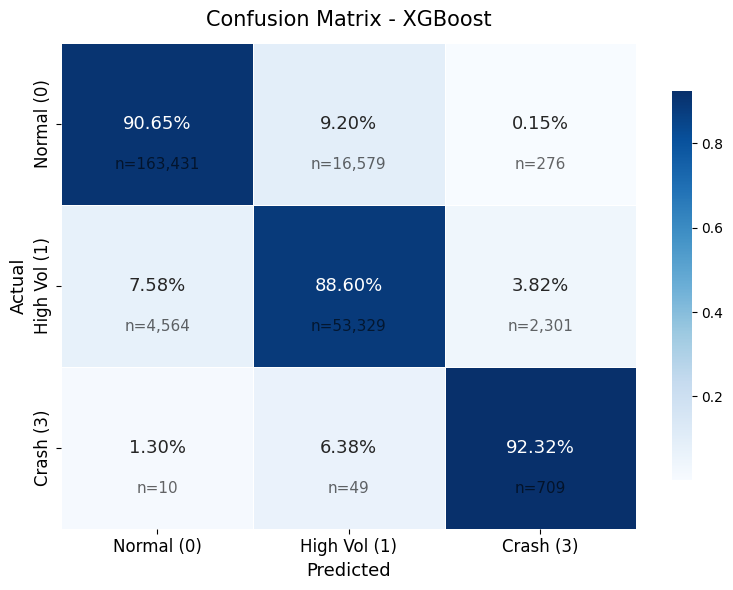

In [5]:
# ── Figure 1: Confusion Matrix
fig1, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
cm      = confusion_matrix(y_test_orig, y_pred, labels=CLASSES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 13, "weight": "normal"})

for i in range(3):
    for j in range(3):
        ax.text(j + 0.5, i + 0.75, f"n={cm[i,j]:,}",
                ha="center", va="center", fontsize=11,
                color="black", alpha=0.6)

ax.set_title("Confusion Matrix - XGBoost", fontsize=15, pad=12)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Actual", fontsize=13)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

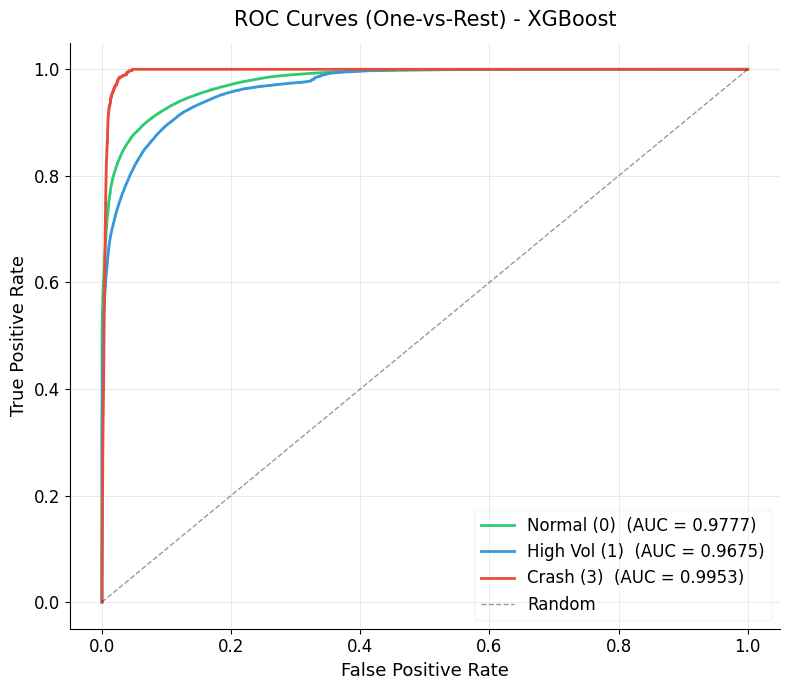

In [6]:
# ── Figure 2: ROC Curves (One-vs-Rest)
fig2, ax = plt.subplots(figsize=(8, 7), facecolor="white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e0e0e0", linewidth=0.5)

y_test_bin = label_binarize(y_test_orig, classes=CLASSES)
prob_map   = {0: LABEL_MAP[0], 1: LABEL_MAP[1], 3: LABEL_MAP[3]}

for i, (cls, color, name) in enumerate(zip(CLASSES, COLORS, CLASS_NAMES)):
    prob_col = y_prob[:, prob_map[cls]]
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob_col)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves (One-vs-Rest) - XGBoost", fontsize=15, pad=12)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, framealpha=0.2)
plt.tight_layout()
plt.show()

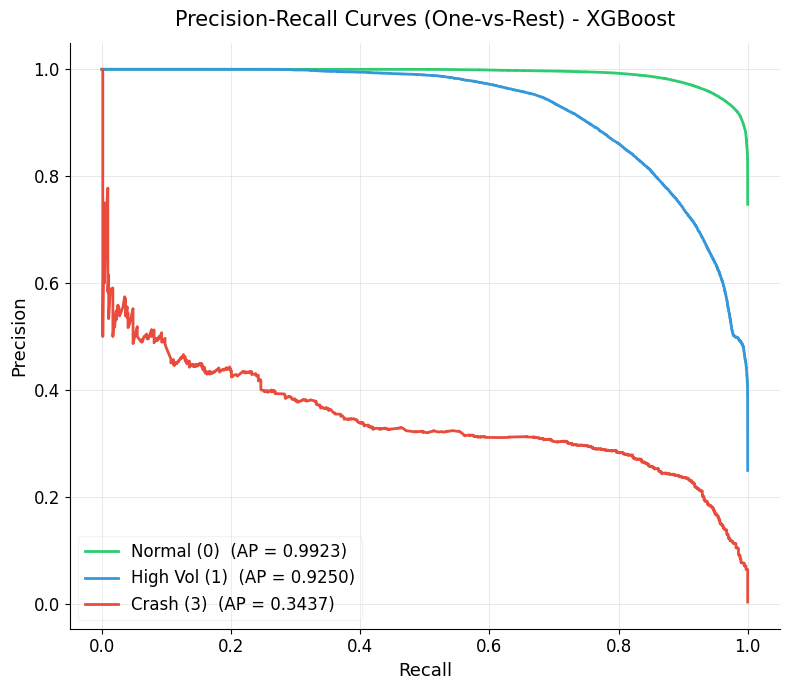

In [7]:
# ── Figure 3: Precision-Recall Curves
fig3, ax = plt.subplots(figsize=(8, 7), facecolor="white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e0e0e0", linewidth=0.5)

for i, (cls, color, name) in enumerate(zip(CLASSES, COLORS, CLASS_NAMES)):
    prob_col = y_prob[:, prob_map[cls]]
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], prob_col)
    ap = average_precision_score(y_test_bin[:, i], prob_col)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name}  (AP = {ap:.4f})")

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision-Recall Curves (One-vs-Rest) - XGBoost", fontsize=15, pad=12)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, framealpha=0.2)
plt.tight_layout()
plt.show()

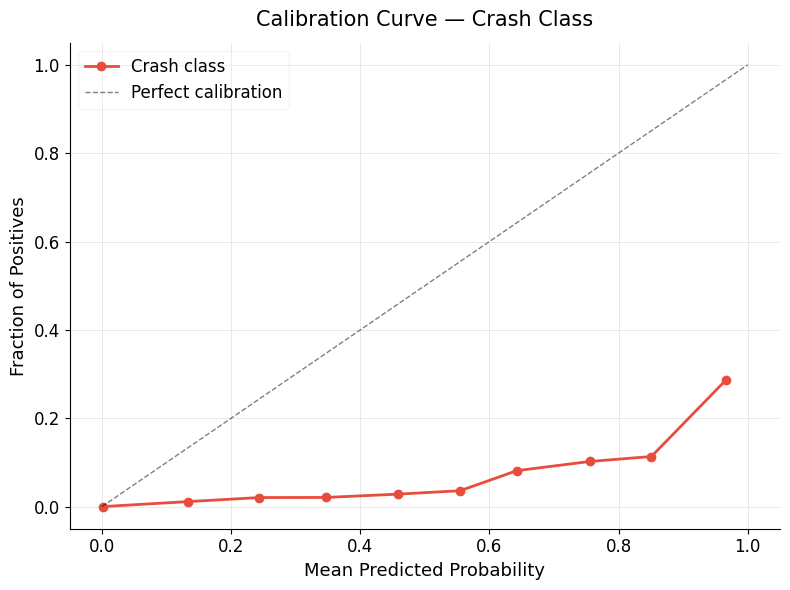

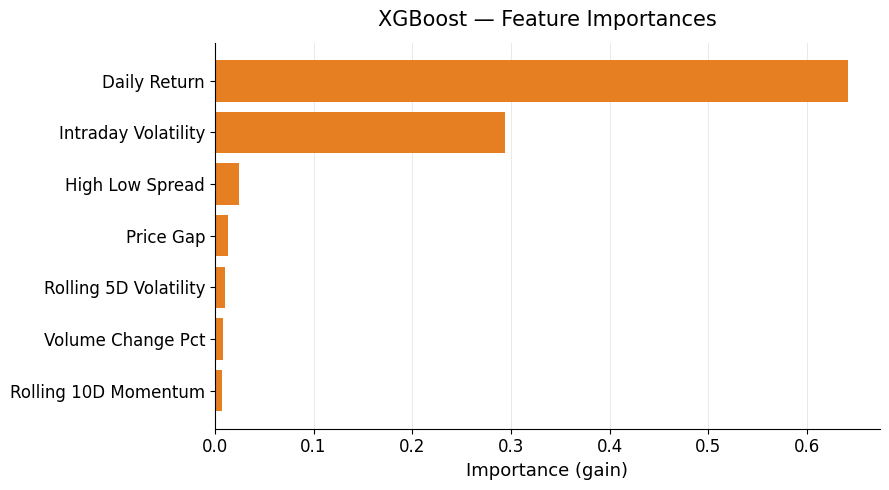


✅ All plots displayed.


In [8]:
# ── Figure 4: Calibration Plot (crash class)
fig4, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e0e0e0", linewidth=0.5)

frac_pos, mean_pred = calibration_curve(
    (y_test_orig == 3).astype(int), prob_crash, n_bins=10
)
ax.plot(mean_pred, frac_pos, "o-", color="#e74c3c", lw=2, label="Crash class")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability", fontsize=13)
ax.set_ylabel("Fraction of Positives", fontsize=13)
ax.set_title("Calibration Curve — Crash Class", fontsize=15, pad=12)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, framealpha=0.2)
plt.tight_layout()
plt.show()

# ── Figure 5: Feature Importances
fig5, ax = plt.subplots(figsize=(9, 5), facecolor="white")
ax.set_facecolor("white")
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(color="#e0e0e0", linewidth=0.5)
ax.set_axisbelow(True)

xgb_model   = best_model.named_steps["xgb"]
importances = xgb_model.feature_importances_
feat_order  = np.argsort(importances)

ax.barh([FEATURES[i].replace("_", " ").title() for i in feat_order],
        importances[feat_order],
        color="#e67e22", edgecolor="none")
ax.set_xlabel("Importance (gain)", fontsize=13)
ax.set_title("XGBoost — Feature Importances", fontsize=15, pad=12)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

print("\n✅ All plots displayed.")
print("=" * 65)